In [2]:
import numpy as np
from sklearn.decomposition import PCA

# ============================================================
# 1. Paths
# ============================================================
VIT_PATH = "/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl"

# ============================================================
# 2. Load ViT logits
# ============================================================
vit = np.load(VIT_PATH, allow_pickle=True)["natural_scenes"]   # (n_images, 1000)
n_images, n_classes = vit.shape

logits = vit  # 118 × 1000 matrix
pca = PCA(n_components=5)
pcs = pca.fit_transform(logits)

vit_pc1 = pcs[:, 0]  # semantic axis
order = np.argsort(vit_pc1)

print("Stimuli sorted by semantic PC1:")
print(order)

Stimuli sorted by semantic PC1:
[ 84  86 114  85  90 113 106  81 115  82  79 108 104 105  69  72  83  95
  65  94  20 111  73  64  43  30  80  99  31  68  98 116  61  87 100  67
  60  40  70  77  62  75  42  71  63  89 109  37 103  59 110  55 112  66
  52   4 102  41  91  74 117  92  76  36 101  24  78  26  19  54  57  96
  18  48  51  56  93  21  28   3  58  49  45  35   8  25  34  46  88  53
  44  11   9  39  47  12 107  97  13  10   1  38  27  23   6  22  33  32
  17   2  16   7  15   5   0  14  50  29]


In [13]:
d_1=vit[84,:]-vit[29,:]
d_2=vit[77,:]-vit[13,:]
print(d_1.shape)

(1000,)


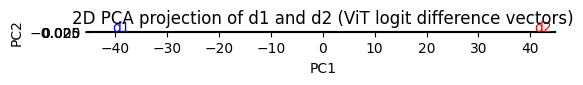

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# d1, d2 already computed as 1000-dim vectors

D = np.vstack([d_1, d_2])  # shape (2, 1000)

# PCA projection to 2D
pca = PCA(n_components=2)
D_2d = pca.fit_transform(D)   # shape (2, 2)

d1_2d = D_2d[0]
d2_2d = D_2d[1]

# Plot
plt.figure(figsize=(6,6))
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)

plt.arrow(0, 0, d1_2d[0], d1_2d[1], 
          head_width=0.05, color='blue', label='d1')
plt.arrow(0, 0, d2_2d[0], d2_2d[1], 
          head_width=0.05, color='red', label='d2')

plt.scatter([0],[0], color='black')

plt.text(d1_2d[0], d1_2d[1], "d1", color='blue')
plt.text(d2_2d[0], d2_2d[1], "d2", color='red')

plt.title("2D PCA projection of d1 and d2 (ViT logit difference vectors)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.gca().set_aspect('equal', 'box')
plt.grid(True)
plt.show()
